# Setting up libraries and device agnostic code

In [1]:
import os
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Optional for confusion matrix (we can remove later if you want zero sklearn)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

# Loading the data and pre-processing it to make it better for the training

In [2]:
IMG_SIZE = 64
BATCH_SIZE = 64
ROOT = "data"

train_transform = transforms.Compose([        #Change each image
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  #Resize to avoid problems and have uniformity in data size
    transforms.RandomHorizontalFlip(),        #To make the model more robust by flipping images (proba 0.5)
    transforms.RandomRotation(15),            #To make the model more robust by rotating it by ±15°
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),  #Normalizing the RGB values to have a more robust and faster training. Values from ImageNet datasets.
                         std=(0.229, 0.224, 0.225))
])

eval_transform = transforms.Compose([         #Except for the resizing, keep the images as it is to test the model, so no change
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

# Take dataset, apply transforms
base_train_ds = datasets.EuroSAT(root=ROOT, download=True, transform=train_transform)
base_eval_ds  = datasets.EuroSAT(root=ROOT, download=True, transform=eval_transform)

class_names = base_train_ds.classes
num_classes = len(class_names)

print("Classes:", class_names)
print('Total features : 12288 ')
print("Num classes:", num_classes)
print("Total samples:", len(base_train_ds))


Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total features : 12288 
Num classes: 10
Total samples: 27000


# Separating data for train, evaluation and test

In [3]:
import numpy as np
from torch.utils.data import Subset

np.random.seed(42)
n = len(base_train_ds)

#Mix indexes
indices = np.random.permutation(n)

n_train = int(0.8 * n)
n_val   = int(0.1 * n)
n_test  = n - n_train - n_val

# Split
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

# Création des subsets
train_ds = Subset(base_train_ds, train_idx)   #with train for robustness
val_ds   = Subset(base_eval_ds,  val_idx)     #with eval
test_ds  = Subset(base_eval_ds,  test_idx)    #with eval

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))


Train: 21600
Val: 2700
Test: 2700


# Making the data appropriate for batches

In [4]:
#Transforming data to batches for the model
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Showing datapoints to have an overview on what the model will learn

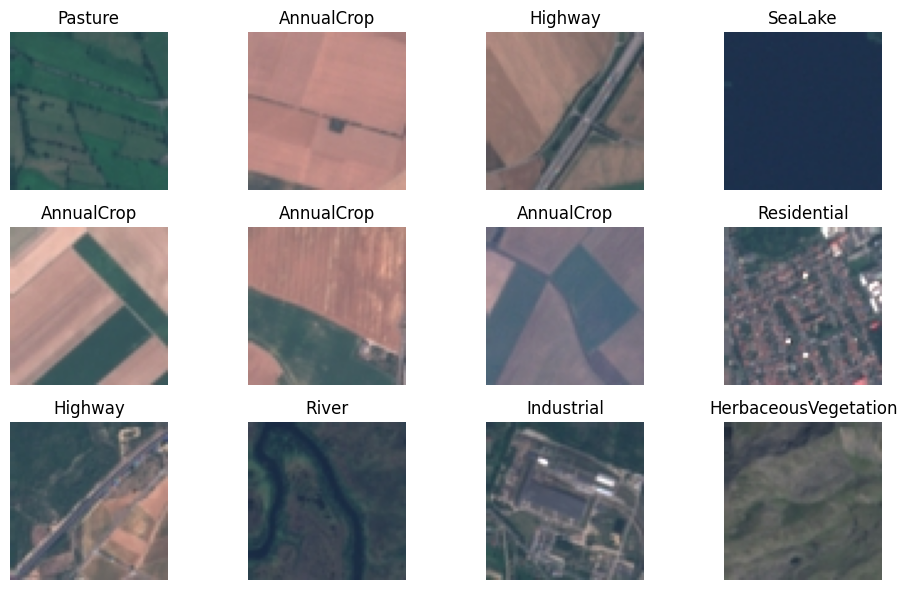

In [5]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

x, y = next(iter(val_loader))

plt.figure(figsize=(10,6))

for i in range(12):
    plt.subplot(3,4,i+1)
    img = (x[i] * std + mean).clamp(0,1)   # denorm to have good colors
    img = img.permute(1,2,0)
    plt.imshow(img)
    plt.title(class_names[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


# Creating the CNN model

In [6]:
class TinyVGG_BN(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int, img_size: int = 64, dropout: float = 0.3):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(input_shape, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(hidden_units, hidden_units*2, 3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.Conv2d(hidden_units*2, hidden_units*2, 3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(hidden_units*2, hidden_units*2, 3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(hidden_units*2 * 8 * 8, output_shape)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = TinyVGG_BN(input_shape=3, hidden_units=32, output_shape=num_classes, img_size=IMG_SIZE).to(device)
model


TinyVGG_BN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1,

# Defining the accuracy function and the training/evaluating process

In [7]:
def accuracy_fn(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

@torch.inference_mode()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        total_loss += loss.item()
        total_acc += accuracy_fn(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_fn(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


# Training the model with the AdamW optimizer

In [8]:
def fit(model, train_loader, val_loader, optimizer, epochs=10, device="cpu"):

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}


    loss_fn = nn.CrossEntropyLoss() #Optimal for multiclass, penalize strongly wrong predictions
    best_val_acc = -1.0
    best_state = None

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn, device)
        scheduler.step(va_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

    return history, best_val_acc, best_state

# Optimizer :AdamW because uses decoupled weight decay for faster convergence (few EPOCHS) and better generalization compared to standard SGD
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

EPOCHS = 10
history, best_val_acc, best_state = fit(model, train_loader, val_loader, optimizer, epochs=EPOCHS, device=device)
print("Best val acc:", best_val_acc)


Epoch 01/10 | train_loss=0.8564 train_acc=0.6908 | val_loss=0.6690 val_acc=0.7647
Epoch 02/10 | train_loss=0.5670 train_acc=0.8004 | val_loss=0.4752 val_acc=0.8327
Epoch 03/10 | train_loss=0.4847 train_acc=0.8324 | val_loss=0.3782 val_acc=0.8711
Epoch 04/10 | train_loss=0.4026 train_acc=0.8612 | val_loss=0.3645 val_acc=0.8752
Epoch 05/10 | train_loss=0.3490 train_acc=0.8786 | val_loss=0.2863 val_acc=0.8985
Epoch 06/10 | train_loss=0.3045 train_acc=0.8947 | val_loss=0.2448 val_acc=0.9167
Epoch 07/10 | train_loss=0.2877 train_acc=0.9000 | val_loss=0.3674 val_acc=0.8749
Epoch 08/10 | train_loss=0.2581 train_acc=0.9105 | val_loss=0.2327 val_acc=0.9196
Epoch 09/10 | train_loss=0.2456 train_acc=0.9169 | val_loss=0.2259 val_acc=0.9165
Epoch 10/10 | train_loss=0.2155 train_acc=0.9260 | val_loss=0.2055 val_acc=0.9243
Best val acc: 0.9242974810822066


# Plotting Loss and Accuracy curves

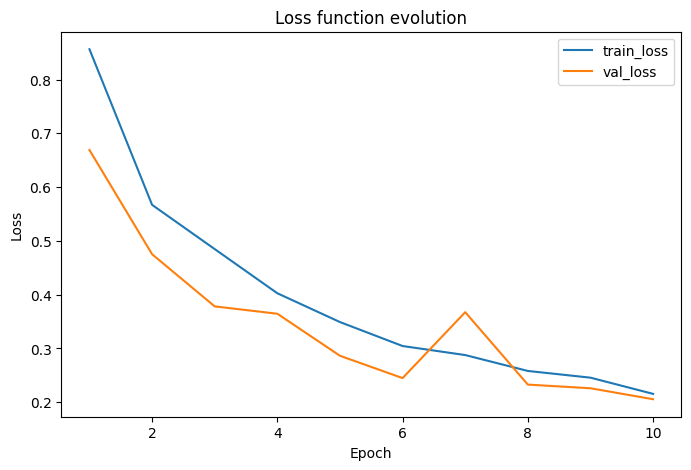

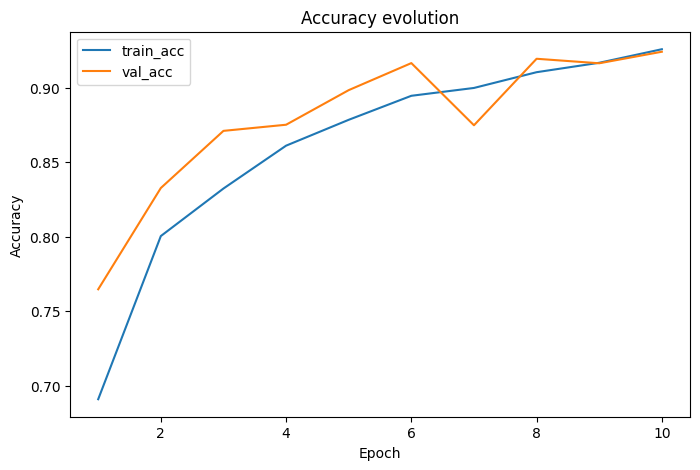

In [10]:
def plot_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_loss'], label="train_loss")
    plt.plot(epochs, history['val_loss'], label="val_loss")
    plt.title('Loss function evolution')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_acc'], label="train_acc")
    plt.plot(epochs, history['val_acc'], label="val_acc")
    plt.title('Accuracy evolution')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_curves(history)

# Final confusion matrix to see how it went for the test set

Test loss: 0.2019731364277906 Test acc: 0.9272044578263926


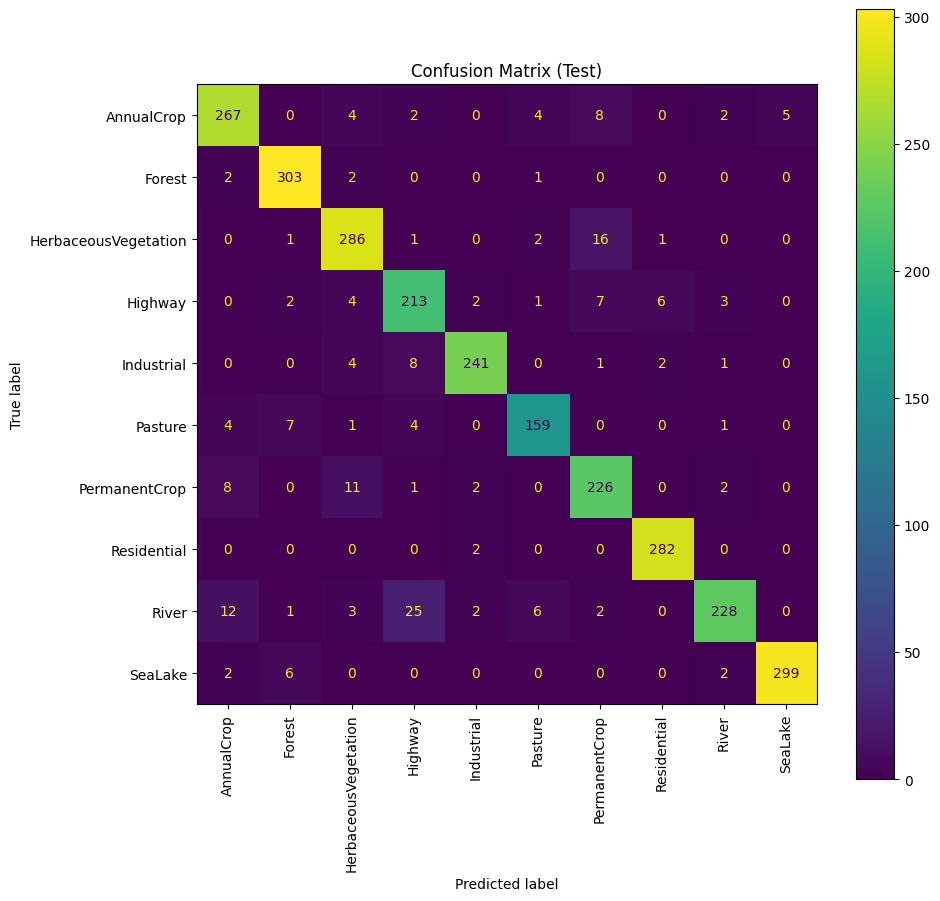

In [11]:
# Restore best weights
best_model = TinyVGG_BN(input_shape=3, hidden_units=32, output_shape=num_classes, img_size=IMG_SIZE).to(device)
best_model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

loss_fn = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, loss_fn, device)
print("Test loss:", test_loss, "Test acc:", test_acc)

@torch.inference_mode()
def get_all_preds(model, loader, device):
    model.eval()
    all_preds, all_true = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_true.append(y)
    return torch.cat(all_preds), torch.cat(all_true)

preds, y_true = get_all_preds(best_model, test_loader, device)

cm = confusion_matrix(y_true.numpy(), preds.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation="vertical", values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()
